In [1]:
import tensorflow as tf
import numpy as np

class MNIST_MLP:
    def __init__(self, learning_rate=0.001):
        # Initialize weights
        initializer = tf.random_normal_initializer(stddev=0.1)

        self.W1 = tf.Variable(initializer([784, 512]))
        self.b1 = tf.Variable(tf.zeros([512]))
        self.W2 = tf.Variable(initializer([512, 10]))
        self.b2 = tf.Variable(tf.zeros([10]))

        self.variables = [self.W1, self.b1, self.W2, self.b2]

        # Loss and optimizer
        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate)

    def forward(self, x):
        hidden = tf.nn.relu(tf.matmul(x, self.W1) + self.b1)
        logits = tf.matmul(hidden, self.W2) + self.b2
        probs = tf.nn.softmax(logits)
        return probs

    @tf.function
    def train_step(self, x_batch, y_batch):
        with tf.GradientTape() as tape:
            probs = self.forward(x_batch)
            loss = self.loss_fn(y_batch, probs)

        grads = tape.gradient(loss, self.variables)
        self.optimizer.apply_gradients(zip(grads, self.variables))
        return loss

    def evaluate(self, x, y):
        probs = self.forward(x)
        preds = tf.argmax(probs, axis=1, output_type=tf.int32)
        accuracy = tf.reduce_mean(
            tf.cast(tf.equal(preds, y), tf.float32)
        )
        return accuracy


In [2]:
# Load data
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test = x_test.reshape(-1, 784).astype("float32") / 255.0

y_train = y_train.astype("int32")
y_test = y_test.astype("int32")

# Create model
model = MNIST_MLP()

# Dataset
batch_size = 128
train_ds = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))
    .shuffle(10000)
    .batch(batch_size)
)

# Train
print("Starting Training...")
for epoch in range(5):
    epoch_loss = 0.0
    steps = 0

    for x_batch, y_batch in train_ds:
        loss = model.train_step(x_batch, y_batch)
        epoch_loss += loss.numpy()
        steps += 1

    print(f"Epoch {epoch+1}, Avg Loss: {epoch_loss/steps:.4f}")

# Evaluate
accuracy = model.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy.numpy() * 100:.2f}%")


Starting Training...
Epoch 1, Avg Loss: 0.2765
Epoch 2, Avg Loss: 0.1084
Epoch 3, Avg Loss: 0.0678
Epoch 4, Avg Loss: 0.0477
Epoch 5, Avg Loss: 0.0341

Final Test Accuracy: 97.94%


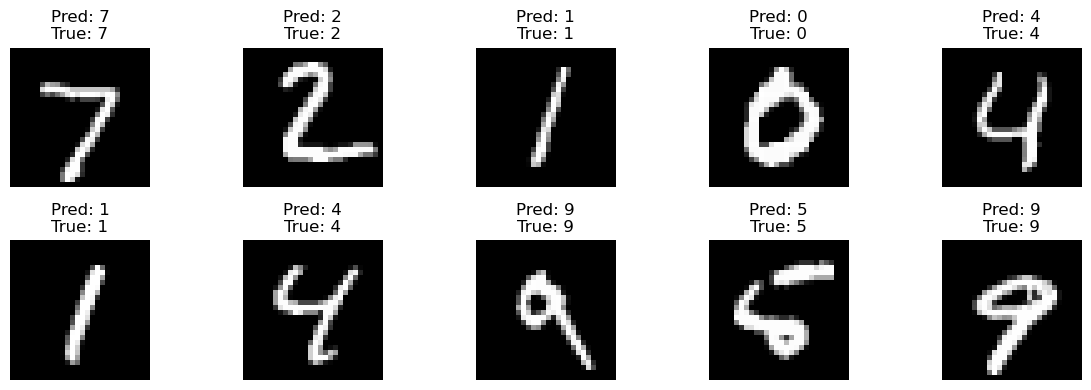

In [5]:
import matplotlib.pyplot as plt

num_samples = 10
images = x_test[:num_samples].reshape(-1, 28, 28)
true_labels = y_test[:num_samples]

# Predictions
probs = model.forward(x_test[:num_samples])
pred_labels = tf.argmax(probs, axis=1).numpy()

plt.figure(figsize=(12, 4))
for i in range(num_samples):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(f"Pred: {pred_labels[i]}\nTrue: {true_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()
